<a href="https://colab.research.google.com/github/Yahir-7/GeoPandas/blob/main/PRISM_Extreme_Heat_2024%262020.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

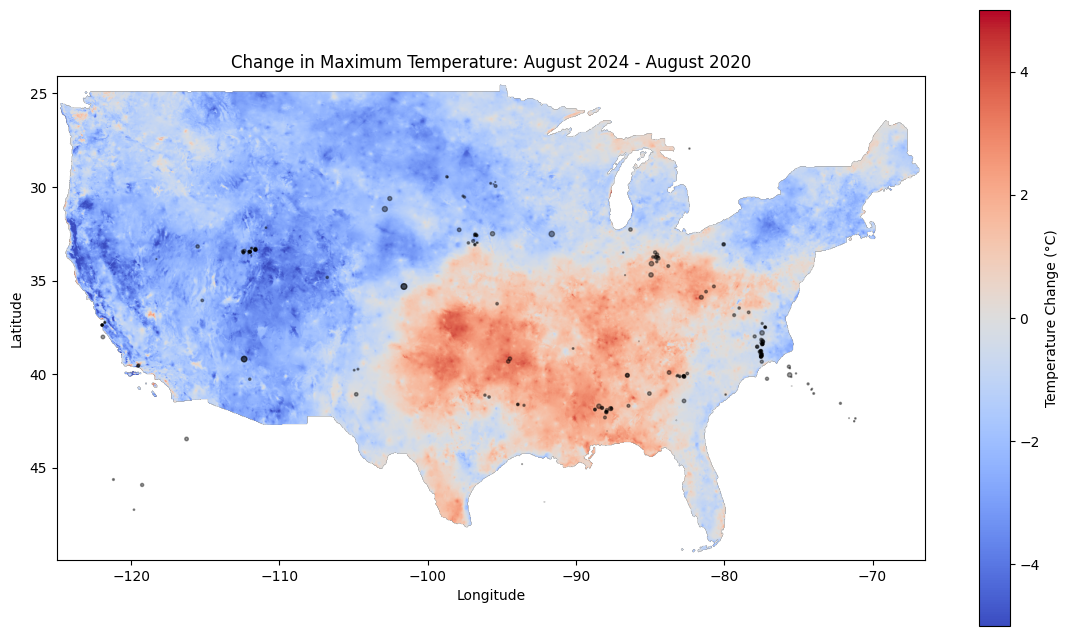

In [7]:
# !pip install geopandas rasterio pandas numpy matplotlib
import numpy as np
import pandas as pd
import geopandas
import rasterio
import matplotlib.pyplot as plt
from rasterio.plot import show

dc = pd.read_excel("/content/Aterio US Data Centers Dashboard.xlsx", sheet_name = "Data Sample")
dc = dc[[
        "DATA_CENTER_BUILDING_NAME",
        "PROVIDER_NAME",
        "DATA_CENTER_STAGE",
        "FULL_ADDRESS",
        "CITY_NAME",
        "STATE_NAME",
        "LOCATION_LATITUDE",
        "LOCATION_LONGITUDE",
        "SELECTED_POWER_CAPACITY_MW",
        "DATA_CENTER_ACTIVATION_DATE",
        "DATA_CENTER_ANNOUNCED_DATE",
        "RECORD_UPDATED_DATE"
    ]
  ]
dc = dc.dropna(subset=["LOCATION_LATITUDE", "LOCATION_LONGITUDE"])
data_centers = geopandas.GeoDataFrame(
    dc, geometry=geopandas.points_from_xy(dc.LOCATION_LONGITUDE, dc.LOCATION_LATITUDE),
    crs= "EPSG:4326"
)
with rasterio.open("/content/prism_tmax_us_25m_202008.tif") as dataset_2020:
  with rasterio.open("/content/prism_tmax_us_25m_202408.tif") as dataset_2024:
    temp_2020 = dataset_2020.read(1)
    temp_2024 = dataset_2024.read(1)

    temp_2020 = np.where(temp_2020 == -9999, np.nan, temp_2020)
    temp_2024 = np.where(temp_2024 == -9999, np.nan, temp_2024)
    # print (temp_2020.shape)
    # print (temp_2024.shape)
    change = temp_2024 - temp_2020
    fig, ax = plt.subplots(figsize=(14,8))
    img = ax.imshow(
        change, extent = [
            dataset_2024.bounds.left, dataset_2024.bounds.right,
            dataset_2024.bounds.top, dataset_2024.bounds.bottom
        ],
        cmap = "coolwarm",
        vmin = -5, vmax  = 5
    )
plt.colorbar(img, ax=ax, label="Temperature Change (°C)")
plt.title("Change in Maximum Temperature: August 2024 - August 2020")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

data_centers.plot(
    ax=ax,
    markersize=dc["SELECTED_POWER_CAPACITY_MW"] / 15,
    alpha=0.4,
    color="black"
)

plt.show()
